In [28]:

import pandas as pd

df = pd.read_csv("clean_model_features.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
print(df.head())

Shape: (9420000, 9)

Columns:
['Timestamp', 'Electron_Flux', 'Total_Magnetic_Field', 'Bx', 'By', 'Bz', 'Solar_Wind_Speed', 'Proton_Density', 'Dynamic_Pressure']

Missing Values:
Timestamp                     0
Electron_Flux           1531296
Total_Magnetic_Field    1531296
Bx                      1531296
By                      1531296
Bz                      1531296
Solar_Wind_Speed              0
Proton_Density                0
Dynamic_Pressure              0
dtype: int64

First 5 Rows:
             Timestamp  Electron_Flux  Total_Magnetic_Field  Bx  By  Bz  \
0  1995-10-10 00:00:00            NaN                   NaN NaN NaN NaN   
1  1995-10-10 00:05:00            NaN                   NaN NaN NaN NaN   
2  1995-10-10 00:10:00            NaN                   NaN NaN NaN NaN   
3  1995-10-10 00:15:00            NaN                   NaN NaN NaN NaN   
4  1995-10-10 00:20:00            NaN                   NaN NaN NaN NaN   

   Solar_Wind_Speed  Proton_Density  Dynamic_Pressure  

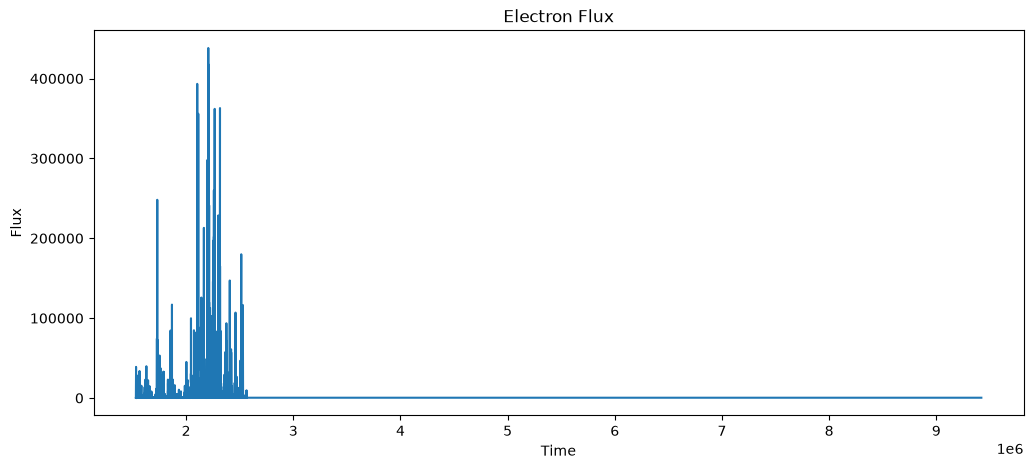

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Electron_Flux"])
plt.title("Electron Flux")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

In [30]:
print(df.shape)
print(df.dropna().shape)

for col in df.columns:
    print(col, df[col].isna().sum())

print(df["Timestamp"].min())
print(df["Timestamp"].max())

(9420000, 9)
(7888704, 9)
Timestamp 0
Electron_Flux 1531296
Total_Magnetic_Field 1531296
Bx 1531296
By 1531296
Bz 1531296
Solar_Wind_Speed 0
Proton_Density 0
Dynamic_Pressure 0
1995-10-10 00:00:00
2085-04-28 07:55:00


In [31]:
print(df["Timestamp"].head())
print(df["Timestamp"].tail())

0    1995-10-10 00:00:00
1    1995-10-10 00:05:00
2    1995-10-10 00:10:00
3    1995-10-10 00:15:00
4    1995-10-10 00:20:00
Name: Timestamp, dtype: str
9419995    2085-04-28 07:35:00
9419996    2085-04-28 07:40:00
9419997    2085-04-28 07:45:00
9419998    2085-04-28 07:50:00
9419999    2085-04-28 07:55:00
Name: Timestamp, dtype: str


In [32]:
import pandas as pd

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(df["Timestamp"].diff().value_counts().head())

Timestamp
0 days 00:05:00    9419999
Name: count, dtype: int64


In [33]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

duration = df["Timestamp"].max() - df["Timestamp"].min()

print(duration)

32708 days 07:55:00


In [34]:
print("Rows:", len(df))
print("Expected rows from date range:",
      duration.total_seconds() / 300)

Rows: 9420000
Expected rows from date range: 9419999.0


In [35]:
clean_df = df.dropna().copy()

print(clean_df.shape)

(7888704, 9)


In [ ]:
corr_cols = [
    "Electron_Flux",
    "Total_Magnetic_Field",
    "Bx",
    "By",
    "Bz",
    "Solar_Wind_Speed",
    "Proton_Density",
    "Dynamic_Pressure"
]

corr = clean_df[corr_cols].corr()

print(
    corr["Electron_Flux"]
    .sort_values(ascending=False)
)

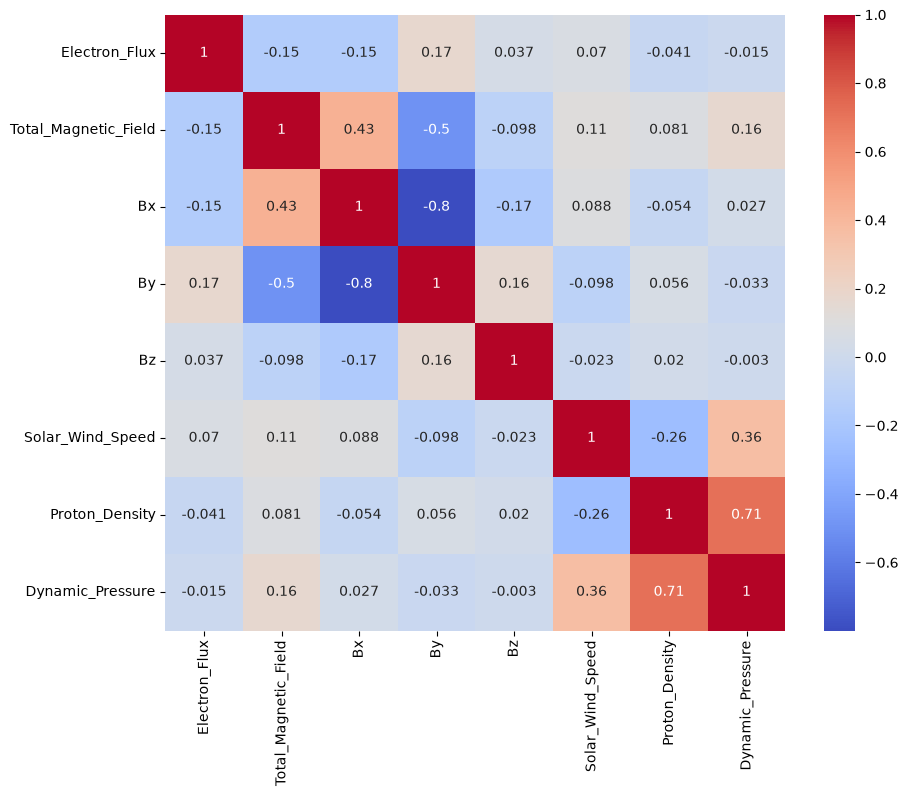

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
clean_df["Flux_1"] = clean_df["Electron_Flux"].shift(1)
clean_df["Flux_3"] = clean_df["Electron_Flux"].shift(3)
clean_df["Flux_6"] = clean_df["Electron_Flux"].shift(6)
clean_df["Flux_12"] = clean_df["Electron_Flux"].shift(12)

In [ ]:
clean_df["Target_45m"] = clean_df["Electron_Flux"].shift(-9)

In [ ]:
model_df = clean_df.dropna()

In [37]:
print(
    model_df[
        [
            "Electron_Flux",
            "Flux_1",
            "Flux_3",
            "Flux_6",
            "Flux_12"
        ]
    ].corr()["Electron_Flux"]
)

Electron_Flux    1.000000
Flux_1           0.997228
Flux_3           0.990872
Flux_6           0.979405
Flux_12          0.954356
Name: Electron_Flux, dtype: float64


In [38]:
features = [
    "Flux_1",
    "Flux_3",
    "Flux_6",
    "Flux_12",
    "Solar_Wind_Speed",
    "Bz",
    "Proton_Density",
    "Dynamic_Pressure",
    "Bx",
    "By",
    "Total_Magnetic_Field"
]

X = model_df[features]
y = model_df["Target_45m"]

In [39]:
split_idx = int(len(model_df) * 0.8)

X_train = X[:split_idx]
X_test  = X[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [40]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
preds = model.predict(X_test)

In [42]:
print(preds)

[343.75732 343.75732 343.75732 ... 344.49994 344.49994 344.49994]


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.12000611872152621
RMSE: 0.12034151508993289
R²  : -1.1204966874215485e+24


In [44]:
print("y_test min:", y_test.min())
print("y_test max:", y_test.max())

print("preds min:", preds.min())
print("preds max:", preds.max())

y_test min: 343.87717
y_test max: 343.87717
preds min: 343.75732
preds max: 344.49994


In [45]:
print(y_test[:10])
print(preds[:10])

7842254    343.87717
7842255    343.87717
7842256    343.87717
7842257    343.87717
7842258    343.87717
7842259    343.87717
7842260    343.87717
7842261    343.87717
7842262    343.87717
7842263    343.87717
Name: Target_45m, dtype: float64
[343.75732 343.75732 343.75732 343.75732 343.75732 343.75732 343.75732
 343.75732 343.75732 343.75732]


In [46]:
print("Unique target values:", y_test.nunique())

Unique target values: 1


In [47]:
print(model_df["Target_45m"].describe())
print(model_df["Target_45m"].nunique())

count    7.888683e+06
mean     7.147980e+02
std      4.675451e+03
min      0.000000e+00
25%      3.438772e+02
50%      3.438772e+02
75%      3.438772e+02
max      4.382157e+05
Name: Target_45m, dtype: float64
1026766


In [48]:
last_value = model_df["Target_45m"].iloc[-1]

mask = model_df["Target_45m"] != last_value

print("Last non-constant index:",
      model_df[mask].index[-1])

Last non-constant index: 2566646


In [49]:
last_value = model_df["Target_45m"].iloc[-1]

constant_rows = (model_df["Target_45m"] == last_value).sum()

print("Constant rows:", constant_rows)
print("Percentage:",
      constant_rows / len(model_df) * 100)

Constant rows: 6853344
Percentage: 86.87564197978294


In [50]:
last_nonconstant_idx = model_df[model_df["Target_45m"] != last_value].index[-1]

In [51]:
usable_df = model_df.loc[:last_nonconstant_idx].copy()

print(usable_df.shape)

(1035339, 14)


In [52]:
print(usable_df["Target_45m"].tail(20))

2566627    446.52994
2566628    439.78882
2566629    448.27045
2566630    473.50122
2566631    487.89142
2566632    483.13535
2566633    462.31406
2566634    457.75446
2566635    410.05682
2566636    413.07990
2566637    411.93150
2566638    400.31510
2566639    404.20523
2566640    395.50668
2566641    414.20575
2566642    384.08258
2566643    372.51077
2566644    372.06412
2566645    357.79602
2566646    351.71710
Name: Target_45m, dtype: float64


In [53]:
X = usable_df[features]
y = usable_df["Target_45m"]

split_idx = int(len(usable_df) * 0.8)

X_train = X[:split_idx]
X_test  = X[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [54]:
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [55]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 469.07065482472507
RMSE: 2702.755326929682
R²  : 0.9048961071824204


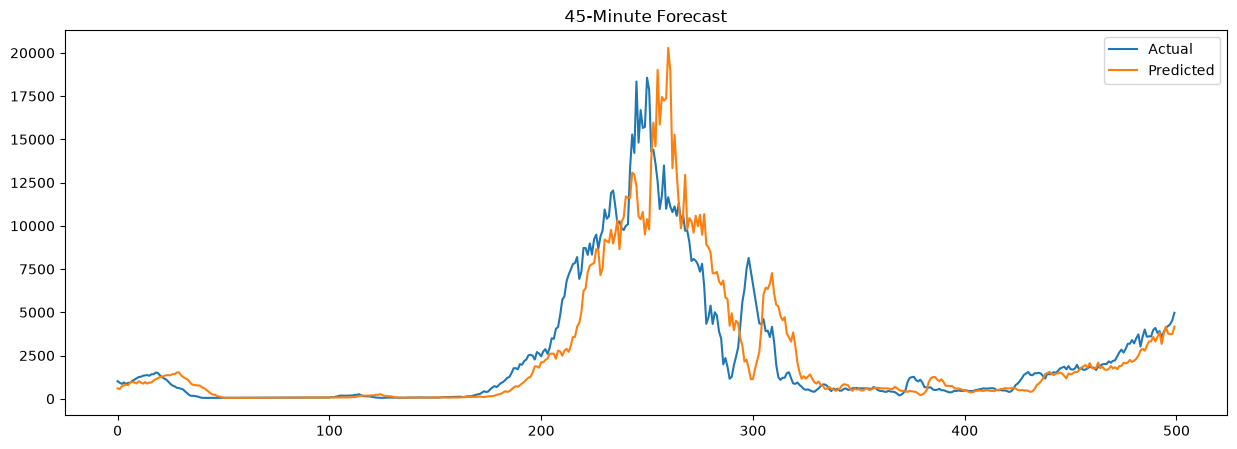

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_test.iloc[:500].values,
         label="Actual")

plt.plot(preds[:500],
         label="Predicted")

plt.legend()
plt.title("45-Minute Forecast")
plt.show()

In [57]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

                 Feature  Importance
0                 Flux_1    0.822008
1                 Flux_3    0.050418
4       Solar_Wind_Speed    0.019369
8                     Bx    0.019054
9                     By    0.015862
10  Total_Magnetic_Field    0.015380
6         Proton_Density    0.014786
7       Dynamic_Pressure    0.013925
2                 Flux_6    0.011591
3                Flux_12    0.009430
5                     Bz    0.008177


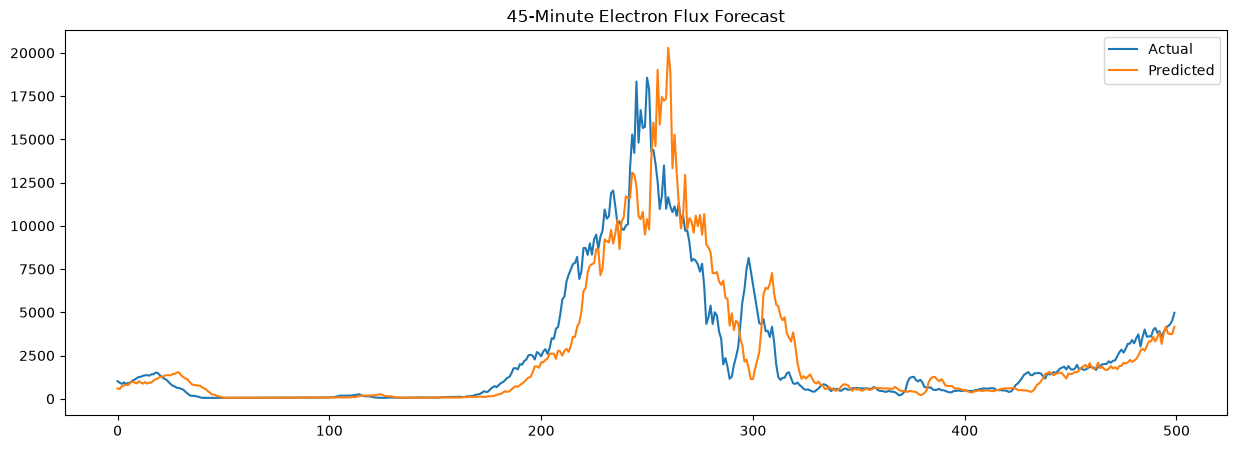

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.iloc[:500].values,
    label="Actual"
)

plt.plot(
    preds[:500],
    label="Predicted"
)

plt.legend()
plt.title("45-Minute Electron Flux Forecast")

plt.show()

In [59]:
model_45m = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

In [60]:
model_45m.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [61]:
preds_45m = model_45m.predict(X_test)

In [62]:
usable_df["Target_6h"] = (
    usable_df["Electron_Flux"].shift(-72)
)

In [63]:
model_6h = usable_df.dropna().copy()

In [64]:
X = model_6h[features]

y = model_6h["Target_6h"]

In [65]:
split_idx = int(len(model_6h) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [66]:
model_6h_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model_6h_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [67]:
preds = model_6h_xgb.predict(X_test)

In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = (
    mean_squared_error(
        y_test,
        preds
    ) ** 0.5
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1781.3805713141865
RMSE: 6652.8569463786125
R²  : 0.423800209085749


In [69]:
usable_df["Target_12h"] = (
    usable_df["Electron_Flux"].shift(-144)
)

In [70]:
model_12h = usable_df.dropna().copy()

In [71]:
X = model_12h[features]

y = model_12h["Target_12h"]

In [72]:
split_idx = int(len(model_12h) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [73]:
model_12h_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model_12h_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [74]:
preds = model_12h_xgb.predict(X_test)

In [75]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = (
    mean_squared_error(
        y_test,
        preds
    ) ** 0.5
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2234.319946382808
RMSE: 7736.222154627678
R²  : 0.22091714656737527


In [76]:
import joblib

joblib.dump(model_45m, "xgboost_45m_model.pkl")
joblib.dump(model_6h_xgb, "xgboost_6h_model.pkl")
joblib.dump(model_12h_xgb, "xgboost_12h_model.pkl")

['xgboost_12h_model.pkl']